--- Loading Dataset ---
Dataset loaded successfully! Total Rows & Columns: (20640, 9)

--- Exploratory Data Analysis ---
Checking for Missing Values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


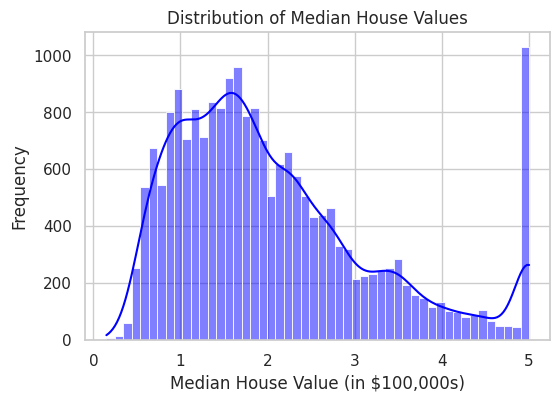

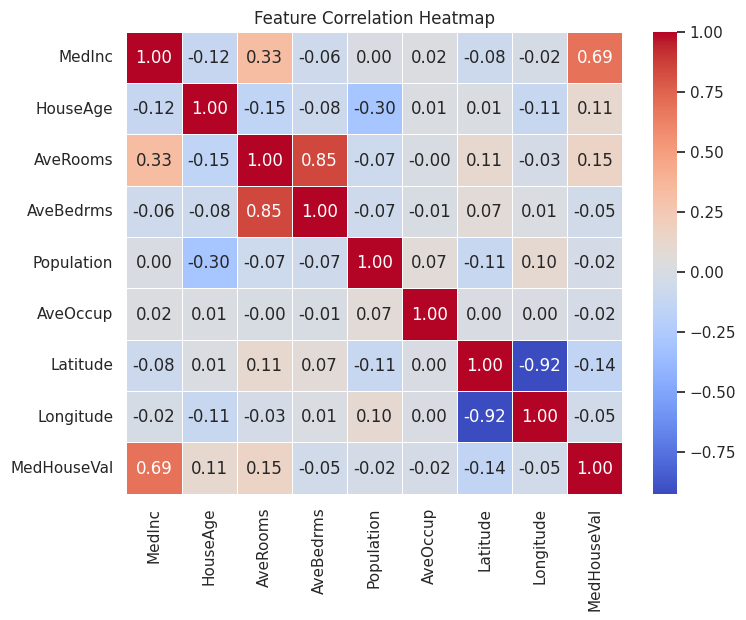


--- Training Linear Regression Model ---
Model trained successfully!

--- Model Evaluation Metrics ---
Mean Absolute Error (MAE): 0.533
Root Mean Squared Error (RMSE): 0.746
R-squared (R²): 0.576


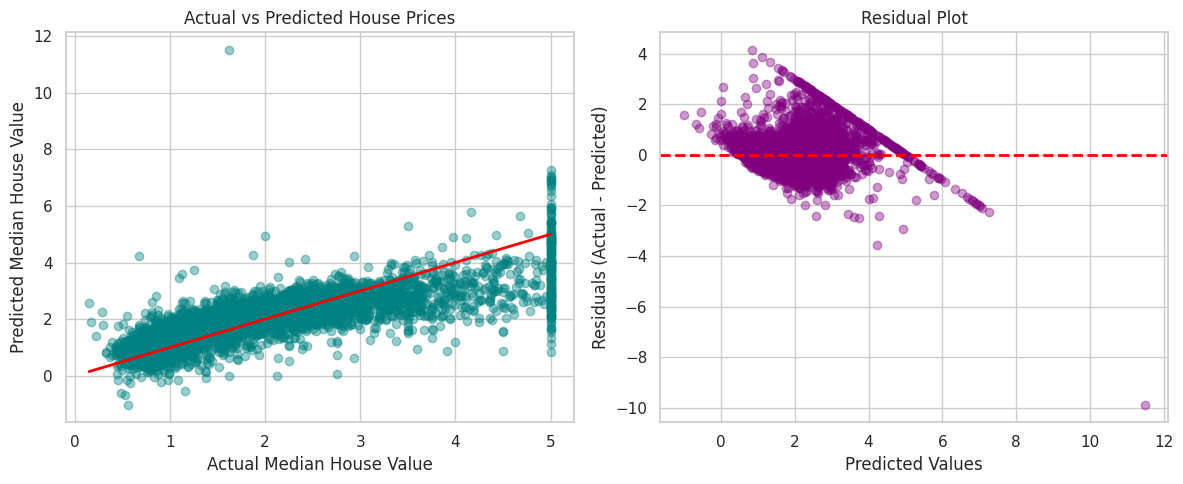

In [2]:
# 1. Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set plot style for better looking graphs
sns.set_theme(style="whitegrid")

# 2. Load Dataset
print("--- Loading Dataset ---")
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename('MedHouseVal')], axis=1)
print(f"Dataset loaded successfully! Total Rows & Columns: {df.shape}")

# 3. EDA (Exploratory Data Analysis)
print("\n--- Exploratory Data Analysis ---")
print("Checking for Missing Values:\n", df.isnull().sum())

# Plot 1: Target Distribution
plt.figure(figsize=(6, 4))
sns.histplot(df['MedHouseVal'], bins=50, kde=True, color='blue')
plt.title("Distribution of Median House Values")
plt.xlabel("Median House Value (in $100,000s)")
plt.ylabel("Frequency")
plt.show()

# Plot 2: Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# 4. Feature Selection & Train/Test Split
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Model Training
print("\n--- Training Linear Regression Model ---")
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Model trained successfully!")

# 6. Evaluation Metrics
print("\n--- Model Evaluation Metrics ---")
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R-squared (R²): {r2:.3f}")

# 7. Visualization: Predicted vs Actual & Residuals
plt.figure(figsize=(12, 5))

# Actual vs Predicted Plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.4, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs Predicted House Prices")

# Residuals Plot
residuals = y_test - y_pred
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, alpha=0.4, color='purple')
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()